In [1]:
import pandas as pd
import glob
import numpy as np
from tqdm import tqdm
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# num_layers = 58
# num_experts = 256
# top_k = 8
# num_layers = 48
# num_experts = 128
# top_k = 8
num_layers = 32
num_experts = 8
top_k = 2

In [3]:
data = np.load('data/mixtral/coactivation_counts_top2.npz')
stats = list(data.values())
len(stats)

256

In [4]:
stats = np.stack(stats).sum(axis=0)
stats

array([[[31050,  8339,  1410, ...,  1947,  4900,  9276],
        [ 8339, 28453,  1564, ...,  1298,   589,  3676],
        [ 1410,  1564, 30383, ...,  8397,  5698,  3455],
        ...,
        [ 1947,  1298,  8397, ..., 37049,  7366,  6550],
        [ 4900,   589,  5698, ...,  7366, 31145,  2516],
        [ 9276,  3676,  3455, ...,  6550,  2516, 36419]],

       [[29508,  3026,  5353, ...,  3858,  4625,  4087],
        [ 3026, 26640,  3794, ...,  2137,  2045,  3129],
        [ 5353,  3794, 29848, ...,  3147,  2889,  2548],
        ...,
        [ 3858,  2137,  3147, ..., 31170,  3046,  7442],
        [ 4625,  2045,  2889, ...,  3046, 30896,  4889],
        [ 4087,  3129,  2548, ...,  7442,  4889, 31097]],

       [[32885,  5248,  3162, ...,  3485,  2239,  7849],
        [ 5248, 34171,  5119, ...,  8873,  2612,  2671],
        [ 3162,  5119, 31719, ...,  4674,  5079,  2278],
        ...,
        [ 3485,  8873,  4674, ..., 35664,  7182,  5870],
        [ 2239,  2612,  5079, ...,  7182, 311

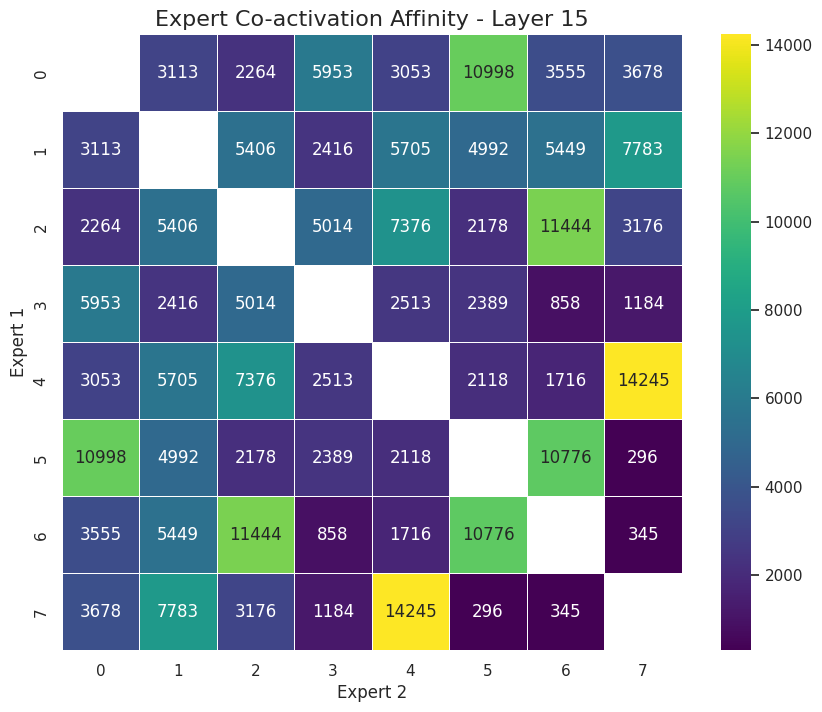

In [5]:
# 1. 模拟您的数据
#    为了使代码可独立运行，我们首先创建一个与您描述相符的示例 `stats` 数组。
#    在您的实际使用中，可以直接使用您自己的 `stats` 数组。

# 创建一个随机的共现计数值，对角线上的值通常会更大

# 2. 设置您想要可视化的层
layer_to_plot = 15  # 您可以修改这个数字，例如 0, 1, ..., 31

# --- 以下是核心绘图代码 ---

# 3. 从 `stats` 数组中提取指定层的数据
affinity_matrix = stats[layer_to_plot]

# 4. 创建一个屏蔽矩阵，用于隐藏对角线上的值 (exp1 = exp2)
#    np.eye(N) 会创建一个 N x N 的单位矩阵 (对角线为1，其余为0)
mask = np.eye(num_experts, dtype=bool)

# 5. 设置绘图参数
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# 6. 使用 seaborn.heatmap 绘图
#    - data: 我们的亲和性矩阵
#    - mask: 应用屏蔽，`True` 的位置将被隐藏
#    - annot=True: 在格子上显示数值
#    - fmt='d': 将数值格式化为整数
#    - cmap: 使用一个美观的颜色映射
heatmap = sns.heatmap(
    affinity_matrix,
    mask=mask,
    annot=True,
    fmt='d',
    cmap='viridis',
    linewidths=.5
)

# 7. 添加标题和标签
heatmap.set_title(f'Expert Co-activation Affinity - Layer {layer_to_plot}', fontdict={'fontsize': 16})
heatmap.set_xlabel('Expert 2')
heatmap.set_ylabel('Expert 1')

# 8. 保存并显示图像
# plt.savefig("expert_affinity_heatmap.png")
plt.show()

In [6]:
assert top_k == 2, "This code is designed for top_k = 2"

def estimate_benefit(exp_coact: np.ndarray):
  exp1, exp2 = np.unravel_index(exp_coact.argsort(axis=None)[::-1], exp_coact.shape)
  used_exp = set()
  total_benefit = 0
  for i in range(exp1.size):
    if exp1[i] == exp2[i]:
      continue
    if exp1[i] in used_exp or exp2[i] in used_exp:
      continue
    used_exp.add(exp1[i])
    used_exp.add(exp2[i])
    # print(f"Using experts {exp1[i]} and {exp2[i]} with co-activation {exp_coact[exp1[i], exp2[i]]}")
    total_benefit += exp_coact[exp1[i], exp2[i]]
  assert len(used_exp) == num_experts
  return total_benefit / exp_coact[~np.eye(num_experts, dtype=bool)].sum()

In [7]:
estimate_benefit(stats[layer_to_plot])

np.float64(0.15040425253667505)

In [8]:
benefits = list(map(estimate_benefit, stats))
benefits = np.stack(benefits)
print(benefits)
print(benefits.min())
print(benefits.max())
print(benefits.mean())
print(benefits.std())


[0.12717993 0.12146808 0.10937897 0.09888225 0.10015155 0.10582493
 0.09566284 0.09115875 0.10755195 0.1252029  0.17414399 0.12666067
 0.12537214 0.1236605  0.12926465 0.15040425 0.12489519 0.14320386
 0.12689529 0.155643   0.11927565 0.11342918 0.1238259  0.13061088
 0.11294839 0.1349265  0.14487319 0.12562984 0.13463802 0.18364835
 0.16985145 0.27546483]
0.09115875470217627
0.2754648327217619
0.13224149569592208
0.03351336421493319


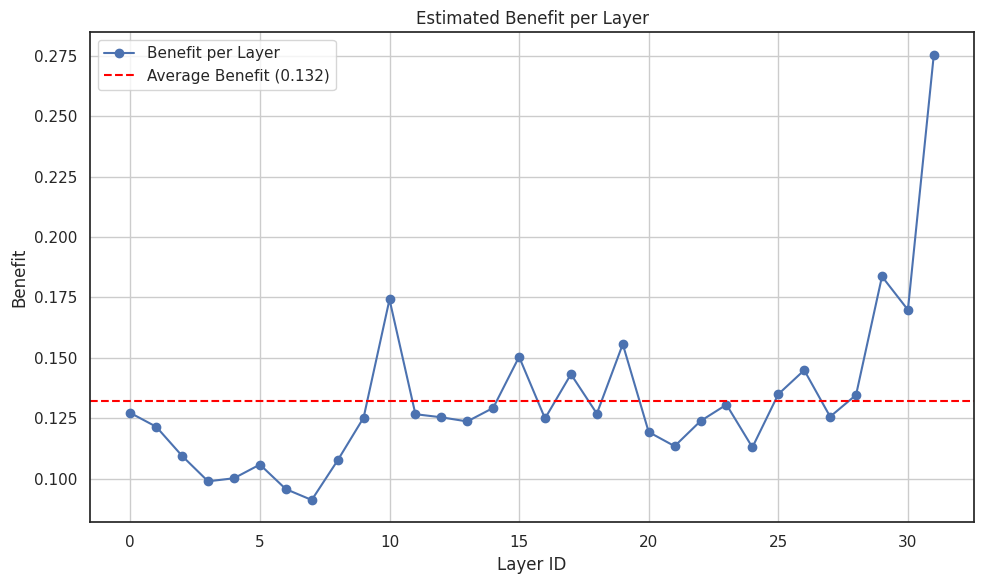

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(num_layers), benefits, marker='o', label='Benefit per Layer')
plt.axhline(benefits.mean(), color='red', linestyle='--', label=f'Average Benefit ({benefits.mean():.3f})')
plt.title('Estimated Benefit per Layer')
plt.xlabel('Layer ID')
plt.ylabel('Benefit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
total_load = np.zeros_like(stats[0], dtype=int)
def estimate_kvload(exp_count):
  total_tokens = np.sum(exp_count, axis=1)[0].item() // top_k
  affine_exp = np.argmax(exp_count, axis=1)
  np.add.at(total_load, (np.arange(num_layers), affine_exp), total_tokens)

for exp_count in stats:
  estimate_kvload(exp_count)

total_load

In [ ]:
# heatmap 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.figure(figsize=(12, 8))
sns.heatmap(total_load+1, annot=False, fmt='d', cmap='viridis', cbar_kws={'label': 'Total Load'}, norm=LogNorm())
plt.title('Total Load per Layer and Expert')
plt.xlabel('Expert ID')
plt.ylabel('Layer ID')
plt.tight_layout()
plt.show()

In [ ]:
# CDF for total_load

plt.figure(figsize=(10, 6))
plt.hist(total_load.flatten(), bins=1000, cumulative=True, density=True, color='blue', alpha=0.7)
plt.title('CDF of Total Load per Layer and Expert')
plt.xlabel('Total Load')
plt.ylabel('Cumulative Density')
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
plt.tight_layout()
plt.show()